In [2]:
# -*- coding: utf-8 -*-
"""NOTEBOOK 02: CLUSTERING Y PCA
Análisis de Segmentación de Hogares
"""

# 🔧 Configuración del notebook
import warnings
warnings.filterwarnings('ignore')

print("🚀 Iniciando Notebook 02: Clustering y PCA")

🚀 Iniciando Notebook 02: Clustering y PCA


In [3]:
# ============================================
# 📚 IMPORTACIÓN DE LIBRERÍAS
# ============================================

# 📊 Manipulación y visualización de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🤖 Preprocesamiento y clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

# 🔧 Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)
%matplotlib inline

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [4]:
# ============================================
# 📂 CARGA DE DATOS PROCESADOS
# ============================================

# Opción 1: Si subiste el archivo manualmente a Colab
df = pd.read_csv('datos_procesados.csv')

# Opción 2: Si montaste Google Drive (descomenta y ajusta la ruta)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/datos_procesados.csv')

print("📊 Dimensiones del dataset:", df.shape)
print("\n📋 Primeros registros:")
df.head()

📊 Dimensiones del dataset: (32764, 13)

📋 Primeros registros:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
0,2,2.0,4.0,2.0,11.0,4,8,6,1.0,45.0,0.000000,3,2.0
1,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0
2,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0
3,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0
4,2,5.0,1.0,1.0,10.0,4,8,6,2.0,33.0,0.333333,3,3.0


In [5]:
# ============================================
# 🔍 EXPLORACIÓN INICIAL DE DATOS
# ============================================

print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
df.info()

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("VALORES NULOS POR COLUMNA")
print("="*60)
print(df.isnull().sum())

print("\n" + "="*60)
print("TIPOS DE DATOS POR COLUMNA")
print("="*60)
print(df.dtypes)

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32764 entries, 0 to 32763
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PERCEPHO        32764 non-null  int64  
 1   P103            32764 non-null  float64
 2   P104            32764 non-null  float64
 3   P105A           32764 non-null  float64
 4   EDUCACION_JEFE  32764 non-null  float64
 5   DOMINIO         32764 non-null  int64  
 6   NUM_SERVICIOS   32764 non-null  int64  
 7   NUM_EQUIPOS     32764 non-null  int64  
 8   NUM_OCUPADOS    32764 non-null  float64
 9   EDAD_JEFE       32764 non-null  float64
 10  PCT_NINOS       32764 non-null  float64
 11  POBREZA         32764 non-null  int64  
 12  HACINAMIENTO    32764 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 3.2 MB

ESTADÍSTICAS DESCRIPTIVAS


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
count,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000,32764.0,32764.0,32764.000000,32764.000000,32764.000000,32764.000000,32764.000000
mean,1.998108,4.683189,3.278293,2.561012,5.549322,4.863234,8.0,6.0,1.665853,54.235075,0.123998,2.782871,2.946040
std,0.996834,1.251797,1.634362,1.490347,2.418221,2.359349,0.0,0.0,1.049892,15.684527,0.178676,0.490776,1.956745
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.0,6.0,0.000000,16.000000,0.000000,1.000000,0.125000
25%,1.000000,4.000000,2.000000,2.000000,4.000000,3.000000,8.0,6.0,1.000000,42.000000,0.000000,3.000000,1.000000
50%,2.000000,5.000000,3.000000,2.000000,6.000000,5.000000,8.0,6.0,2.000000,54.000000,0.000000,3.000000,3.000000
75%,2.000000,6.000000,4.000000,2.000000,7.000000,7.000000,8.0,6.0,2.000000,66.000000,0.250000,3.000000,4.000000
max,9.000000,7.000000,15.000000,7.000000,12.000000,8.000000,8.0,6.0,9.000000,98.000000,0.833333,3.000000,16.000000



VALORES NULOS POR COLUMNA
PERCEPHO          0
P103              0
P104              0
P105A             0
EDUCACION_JEFE    0
DOMINIO           0
NUM_SERVICIOS     0
NUM_EQUIPOS       0
NUM_OCUPADOS      0
EDAD_JEFE         0
PCT_NINOS         0
POBREZA           0
HACINAMIENTO      0
dtype: int64

TIPOS DE DATOS POR COLUMNA
PERCEPHO            int64
P103              float64
P104              float64
P105A             float64
EDUCACION_JEFE    float64
DOMINIO             int64
NUM_SERVICIOS       int64
NUM_EQUIPOS         int64
NUM_OCUPADOS      float64
EDAD_JEFE         float64
PCT_NINOS         float64
POBREZA             int64
HACINAMIENTO      float64
dtype: object


In [6]:
# ============================================
# 🧹 PREPARACIÓN DE DATOS PARA CLUSTERING
# ============================================

# 📌 Seleccionar todas las columnas numéricas para clustering
# Si hay columnas que NO deben usarse (ej: identificadores), eliminarlas aquí
# X = df.drop(['PERCEPHO', 'P103', 'P104', 'P105A'], axis=1)  # Ajustar según caso

# ✅ Usamos todas las columnas (todas son numéricas)
X = df.copy()

print("✅ Variables seleccionadas para clustering:")
print(f"📊 Total de características: {X.shape[1]}")
print(f"📊 Total de registros: {X.shape[0]}")
print("\n📋 Columnas utilizadas:")
print(X.columns.tolist())

✅ Variables seleccionadas para clustering:
📊 Total de características: 13
📊 Total de registros: 32764

📋 Columnas utilizadas:
['PERCEPHO', 'P103', 'P104', 'P105A', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'POBREZA', 'HACINAMIENTO']


In [7]:
# ============================================
# 📊 NORMALIZACIÓN CON STANDARDSCALER
# ============================================

# 🔧 Inicializar y aplicar StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📋 Convertir a DataFrame para mejor visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Datos normalizados correctamente")
print("\n📊 Estadísticas de los datos normalizados:")
display(X_scaled_df.describe())

print("\n📋 Primeros registros normalizados:")
X_scaled_df.head()

✅ Datos normalizados correctamente

📊 Estadísticas de los datos normalizados:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
count,3.276400e+04,3.276400e+04,3.276400e+04,3.276400e+04,3.276400e+04,3.276400e+04,32764.0,32764.0,3.276400e+04,3.276400e+04,3.276400e+04,3.276400e+04,3.276400e+04
mean,1.522406e-16,1.682887e-16,-5.898780e-17,-5.248179e-17,2.255416e-17,3.946978e-17,0.0,0.0,-1.101684e-16,9.021663e-17,4.814445e-17,-2.960233e-16,-3.218305e-16
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,0.0,0.0,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-2.004484e+00,-2.942366e+00,-1.394017e+00,-1.047431e+00,-1.881297e+00,-1.637440e+00,0.0,0.0,-1.586714e+00,-2.437795e+00,-6.939910e-01,-3.632812e+00,-1.441722e+00
25%,-1.001293e+00,-5.457747e-01,-7.821479e-01,-3.764362e-01,-6.406965e-01,-7.897358e-01,0.0,0.0,-6.342206e-01,-7.800849e-01,-6.939910e-01,4.424252e-01,-9.945443e-01
50%,1.898360e-03,2.530889e-01,-1.702790e-01,-3.764362e-01,1.863702e-01,5.796855e-02,0.0,0.0,3.182731e-01,-1.498794e-02,-6.939910e-01,4.424252e-01,2.757707e-02
75%,1.898360e-03,1.051952e+00,4.415899e-01,-3.764362e-01,5.999036e-01,9.056729e-01,0.0,0.0,3.182731e-01,7.501090e-01,7.052075e-01,4.424252e-01,5.386378e-01
max,7.024237e+00,1.850816e+00,7.172148e+00,2.978538e+00,2.667571e+00,1.329525e+00,0.0,0.0,6.985729e+00,2.790367e+00,3.970004e+00,4.424252e-01,6.671366e+00



📋 Primeros registros normalizados:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO
0,0.001898,-2.143502,0.441590,-0.376436,2.254037,-0.365884,0.0,0.0,-0.634221,-0.588811,-0.693991,0.442425,-0.483484
1,0.001898,0.253089,-0.170279,-0.376436,0.186370,-0.365884,0.0,0.0,0.318273,-0.780085,1.171607,0.442425,1.560759
2,0.001898,0.253089,-0.170279,-0.376436,1.013437,-0.365884,0.0,0.0,0.318273,-0.652569,1.171607,0.442425,0.027577
3,-1.001293,0.253089,-0.782148,-0.376436,-1.881297,-0.365884,0.0,0.0,-0.634221,1.515206,-0.693991,0.442425,-0.994544
4,0.001898,0.253089,-1.394017,-1.047431,1.840504,-0.365884,0.0,0.0,0.318273,-1.353908,1.171607,0.442425,0.027577


🔍 Aplicando PCA...


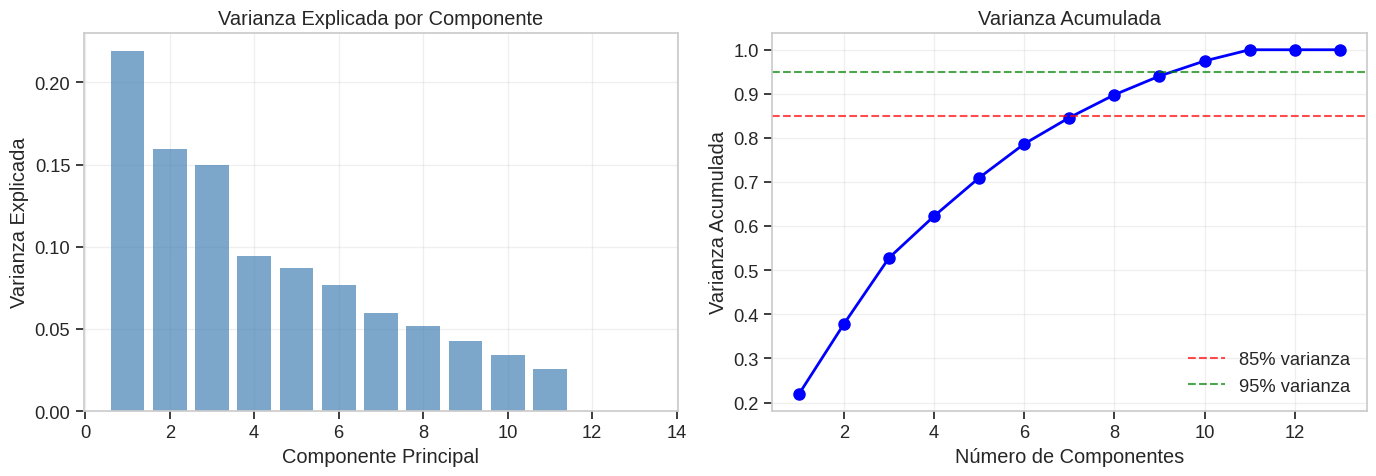


✅ Componentes necesarios para 95% de varianza: 10
✅ Datos reducidos de 13 a 10 dimensiones
📊 Varianza explicada total: 97.46%


In [8]:
# ============================================
# 📉 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
# ============================================

print("🔍 Aplicando PCA...")

# Aplicar PCA completo
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 📊 Calcular varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# 📈 Gráfico de varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Varianza por componente
ax1.bar(range(1, len(varianza_explicada)+1), varianza_explicada,
        alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Varianza acumulada
ax2.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
         'bo-', linewidth=2, markersize=8)
ax2.axhline(y=0.85, color='red', linestyle='--', label='85% varianza', alpha=0.7)
ax2.axhline(y=0.95, color='green', linestyle='--', label='95% varianza', alpha=0.7)
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 📌 Elegir número de componentes (95% de varianza)
n_componentes = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"\n✅ Componentes necesarios para 95% de varianza: {n_componentes}")

# Aplicar PCA con el número de componentes elegido
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_scaled)

print(f"✅ Datos reducidos de {X_scaled.shape[1]} a {n_componentes} dimensiones")
print(f"📊 Varianza explicada total: {varianza_acumulada[n_componentes-1]:.2%}")

🔍 Calculando K óptimo con método del codo...


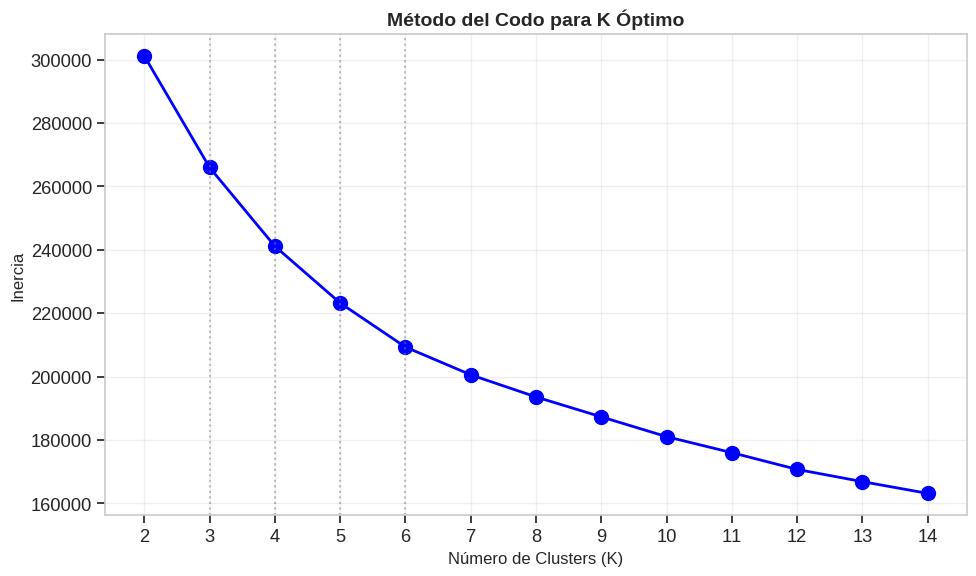


🔍 El punto de quiebre (codo) parece estar entre K=3 y K=6
📌 Validaremos con el coeficiente de silueta


In [9]:
# ============================================
# 🎯 DETERMINACIÓN DEL K ÓPTIMO
# ============================================

print("🔍 Calculando K óptimo con método del codo...")

# Rango de K a evaluar
K_range = range(2, 15)
inercia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_final)
    inercia.append(kmeans.inertia_)

# 📈 Gráfico del método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inercia, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del Codo para K Óptimo', fontsize=14, fontweight='bold')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Resaltar posibles puntos de quiebre
for k in [3, 4, 5, 6]:
    plt.axvline(x=k, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n🔍 El punto de quiebre (codo) parece estar entre K=3 y K=6")
print("📌 Validaremos con el coeficiente de silueta")

🔍 Calculando coeficiente de silueta...
  K=2: Silhouette Score = 0.1424
  K=3: Silhouette Score = 0.1554
  K=4: Silhouette Score = 0.1558
  K=5: Silhouette Score = 0.1629
  K=6: Silhouette Score = 0.1585
  K=7: Silhouette Score = 0.1197
  K=8: Silhouette Score = 0.1161
  K=9: Silhouette Score = 0.1212
  K=10: Silhouette Score = 0.1308
  K=11: Silhouette Score = 0.1295
  K=12: Silhouette Score = 0.1273
  K=13: Silhouette Score = 0.1296
  K=14: Silhouette Score = 0.1225

✅ K óptimo según coeficiente de silueta: 5
   Silhouette Score: 0.1629


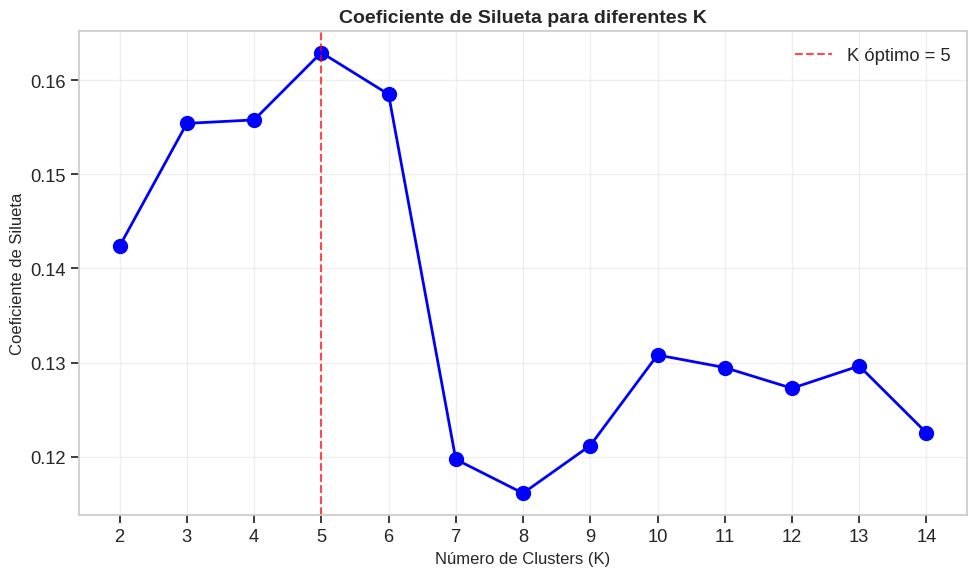

In [10]:
# ============================================
# 📊 VALIDACIÓN CON COEFICIENTE DE SILUETA
# ============================================

print("🔍 Calculando coeficiente de silueta...")

silhouette_scores = []
silhouette_results = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_final)
    score = silhouette_score(X_pca_final, labels)
    silhouette_scores.append(score)
    silhouette_results.append((k, score))
    print(f"  K={k}: Silhouette Score = {score:.4f}")

# Encontrar el K con mejor silueta
k_optimo = range(2, 15)[np.argmax(silhouette_scores)]
print(f"\n✅ K óptimo según coeficiente de silueta: {k_optimo}")
print(f"   Silhouette Score: {max(silhouette_scores):.4f}")

# 📈 Gráfico de scores de silueta
plt.figure(figsize=(10, 6))
plt.plot(range(2, 15), silhouette_scores, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Coeficiente de Silueta', fontsize=12)
plt.title('Coeficiente de Silueta para diferentes K', fontsize=14, fontweight='bold')
plt.xticks(range(2, 15))
plt.grid(True, alpha=0.3)

# Resaltar el mejor K
plt.axvline(x=k_optimo, color='red', linestyle='--', alpha=0.7,
            label=f'K óptimo = {k_optimo}')
plt.legend()
plt.tight_layout()
plt.show()

🎯 Aplicando K-Means con K=5...

📊 Distribución de clusters (K-Means):
  Cluster 0: 5853 registros (17.9%)
  Cluster 1: 4331 registros (13.2%)
  Cluster 2: 10360 registros (31.6%)
  Cluster 3: 6286 registros (19.2%)
  Cluster 4: 5934 registros (18.1%)


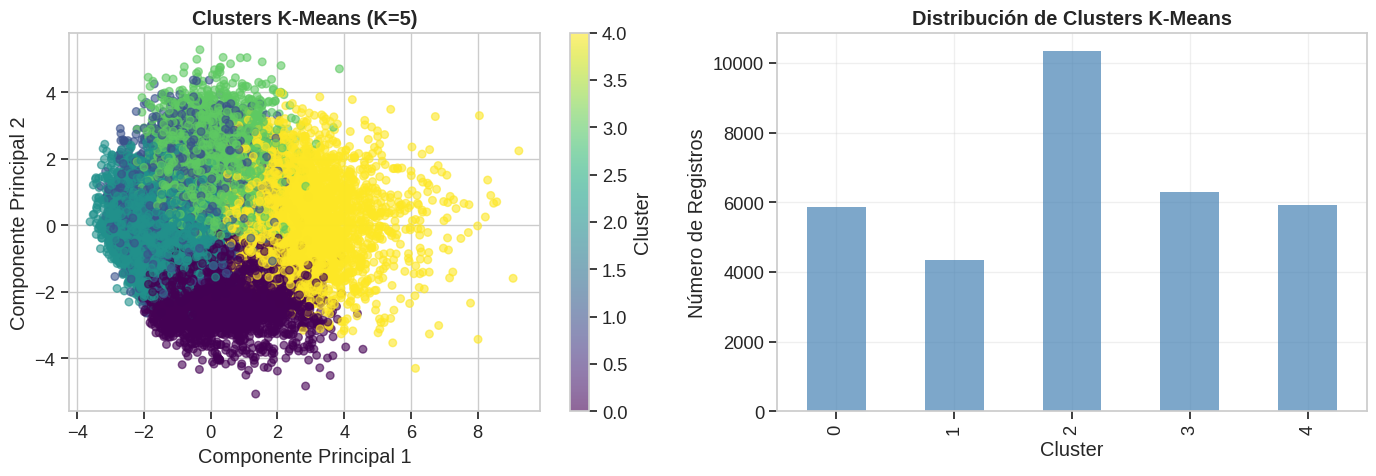


📊 Métricas de calidad:
  Silhouette Score: 0.1629
  Inercia: 223213.26


In [11]:
# ============================================
# 🔬 APLICACIÓN DE K-MEANS
# ============================================

print(f"🎯 Aplicando K-Means con K={k_optimo}...")

# Aplicar K-Means
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_pca_final)

# 📊 Distribución de clusters
print("\n📊 Distribución de clusters (K-Means):")
cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} registros ({count/len(df)*100:.1f}%)")

# 📈 Visualización de clusters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Clusters en 2D
scatter1 = ax1.scatter(X_pca_final[:, 0], X_pca_final[:, 1],
                      c=df['cluster_kmeans'], cmap='viridis', alpha=0.6, s=30)
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
ax1.set_title(f'Clusters K-Means (K={k_optimo})', fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Gráfico 2: Distribución de clusters
cluster_counts.plot(kind='bar', ax=ax2, color='steelblue', alpha=0.7)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Número de Registros')
ax2.set_title('Distribución de Clusters K-Means', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 📊 Métricas de calidad
silhouette_kmeans = silhouette_score(X_pca_final, df['cluster_kmeans'])
print(f"\n📊 Métricas de calidad:")
print(f"  Silhouette Score: {silhouette_kmeans:.4f}")
print(f"  Inercia: {kmeans.inertia_:.2f}")

🔍 Buscando mejores parámetros para DBSCAN...

📊 Probando combinaciones de parámetros:
  eps=0.3, min_samples= 7 → clusters= 9, ruido=32682, silueta=0.5961
  eps=1.3, min_samples=10 → clusters= 9, ruido=4478, silueta=-0.0030

✅ Mejores parámetros: eps=0.3, min_samples=7
   Mejor silueta: 0.5961

📊 Distribución de clusters (DBSCAN):
  Ruido (-1): 32682 registros (99.7%)
  Cluster 0: 13 registros (0.0%)
  Cluster 1: 8 registros (0.0%)
  Cluster 2: 12 registros (0.0%)
  Cluster 3: 8 registros (0.0%)
  Cluster 4: 7 registros (0.0%)
  Cluster 5: 8 registros (0.0%)
  Cluster 6: 12 registros (0.0%)
  Cluster 7: 7 registros (0.0%)
  Cluster 8: 7 registros (0.0%)


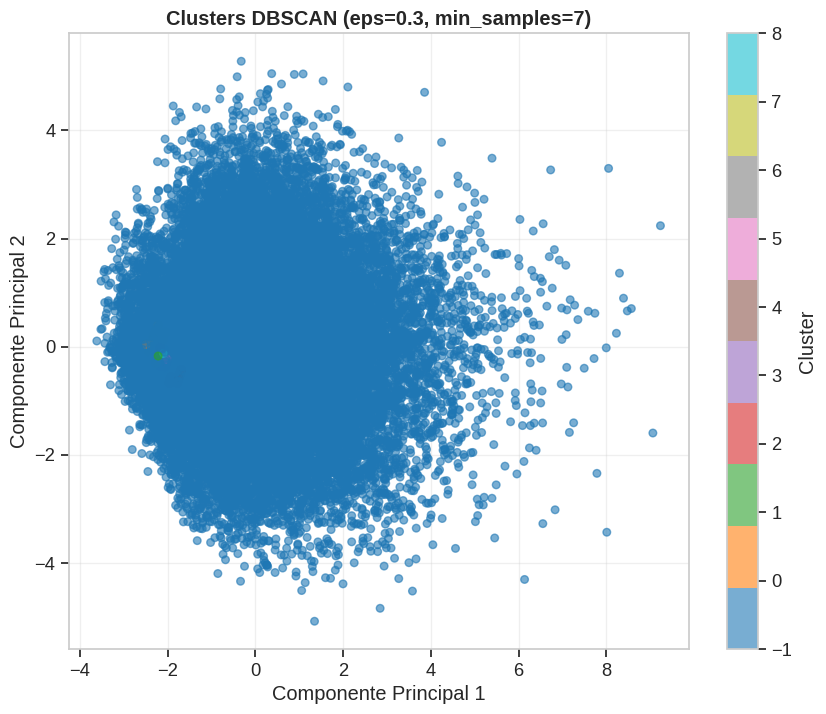

In [12]:
# ============================================
# 🔬 APLICACIÓN DE DBSCAN
# ============================================

print("🔍 Buscando mejores parámetros para DBSCAN...")

# Probar diferentes parámetros
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [3, 5, 7, 10]

best_score = -1
best_params = None
best_labels = None

print("\n📊 Probando combinaciones de parámetros:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca_final)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if 1 < n_clusters < 10:
            mask = labels != -1
            if sum(mask) > 1:
                try:
                    score = silhouette_score(X_pca_final[mask], labels[mask])
                    print(f"  eps={eps:.1f}, min_samples={min_samples:2d} → clusters={n_clusters:2d}, ruido={n_noise:3d}, silueta={score:.4f}")
                    if score > best_score:
                        best_score = score
                        best_params = (eps, min_samples)
                        best_labels = labels
                except:
                    pass

# Usar mejores parámetros o valores por defecto
if best_labels is None:
    print("\n⚠️ No se encontraron combinaciones óptimas. Usando valores por defecto.")
    dbscan = DBSCAN(eps=0.8, min_samples=5)
    best_labels = dbscan.fit_predict(X_pca_final)
    best_params = (0.8, 5)
else:
    print(f"\n✅ Mejores parámetros: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"   Mejor silueta: {best_score:.4f}")

df['cluster_dbscan'] = best_labels

# 📊 Distribución de clusters DBSCAN
print("\n📊 Distribución de clusters (DBSCAN):")
cluster_counts_db = df['cluster_dbscan'].value_counts().sort_index()
for cluster, count in cluster_counts_db.items():
    if cluster == -1:
        print(f"  Ruido (-1): {count} registros ({count/len(df)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} registros ({count/len(df)*100:.1f}%)")

# 📈 Visualización de clusters DBSCAN
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1],
                     c=df['cluster_dbscan'], cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title(f'Clusters DBSCAN (eps={best_params[0]}, min_samples={best_params[1]})',
          fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

🌳 Aplicando Clustering Jerárquico...
📌 Usando K=5 clusters

📊 Evaluando métodos de linkage:
  Linkage='ward': Silhouette Score = 0.1253
  Linkage='average': Silhouette Score = 0.2445
  Linkage='complete': Silhouette Score = 0.0696

✅ Mejor método: linkage='average'
   Silhouette Score: 0.2445

📊 Distribución de clusters (Jerárquico):
  Cluster 0: 32457 registros (99.1%)
  Cluster 1: 98 registros (0.3%)
  Cluster 2: 205 registros (0.6%)
  Cluster 3: 1 registros (0.0%)
  Cluster 4: 3 registros (0.0%)


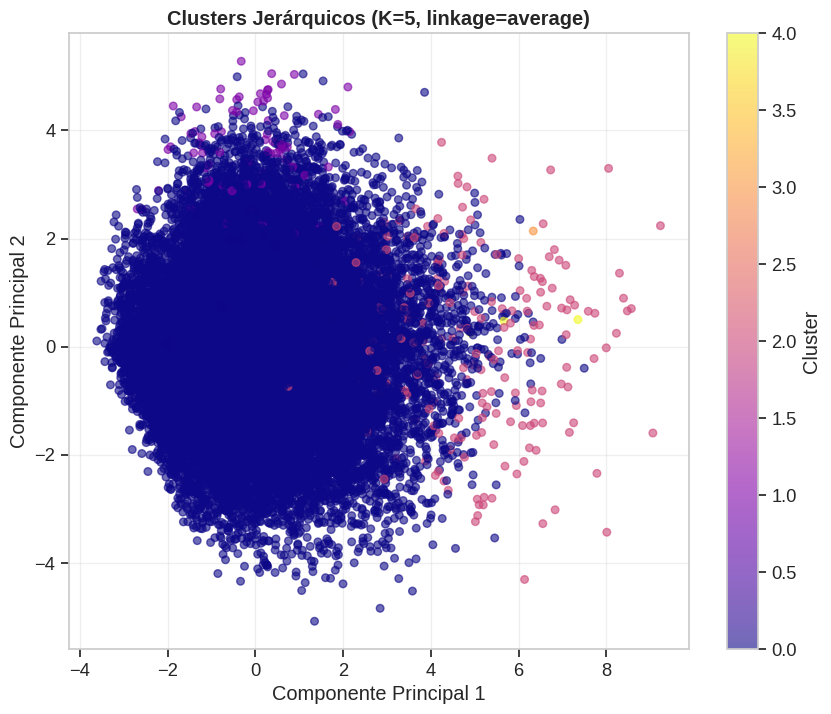

In [13]:
# ============================================
# 🌳 CLUSTERING JERÁRQUICO
# ============================================

print("🌳 Aplicando Clustering Jerárquico...")

# Usar el mismo número de clusters que K-Means
n_clusters_hier = k_optimo
print(f"📌 Usando K={n_clusters_hier} clusters")

# Probar diferentes métodos de linkage
linkage_methods = ['ward', 'average', 'complete']
best_hier_score = -1
best_hier_method = None
best_hier_labels = None

print("\n📊 Evaluando métodos de linkage:")
for method in linkage_methods:
    try:
        hierarchical = AgglomerativeClustering(n_clusters=n_clusters_hier, linkage=method)
        labels_hier = hierarchical.fit_predict(X_pca_final)
        score = silhouette_score(X_pca_final, labels_hier)
        print(f"  Linkage='{method}': Silhouette Score = {score:.4f}")
        if score > best_hier_score:
            best_hier_score = score
            best_hier_method = method
            best_hier_labels = labels_hier
    except Exception as e:
        print(f"  Linkage='{method}': Error - {str(e)}")

# Aplicar el mejor método
hierarchical = AgglomerativeClustering(n_clusters=n_clusters_hier,
                                       linkage=best_hier_method)
df['cluster_hierarchical'] = hierarchical.fit_predict(X_pca_final)

print(f"\n✅ Mejor método: linkage='{best_hier_method}'")
print(f"   Silhouette Score: {best_hier_score:.4f}")

# 📊 Distribución de clusters jerárquicos
print("\n📊 Distribución de clusters (Jerárquico):")
cluster_counts_hier = df['cluster_hierarchical'].value_counts().sort_index()
for cluster, count in cluster_counts_hier.items():
    print(f"  Cluster {cluster}: {count} registros ({count/len(df)*100:.1f}%)")

# 📈 Visualización de clusters jerárquicos
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1],
                     c=df['cluster_hierarchical'], cmap='plasma', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title(f'Clusters Jerárquicos (K={n_clusters_hier}, linkage={best_hier_method})',
          fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

📊 Comparando métodos de clustering...


,Método,N° Clusters,Silhouette Score
0,K-Means,5,0.162939
1,DBSCAN,9,0.596071
2,Jerárquico,5,0.244453


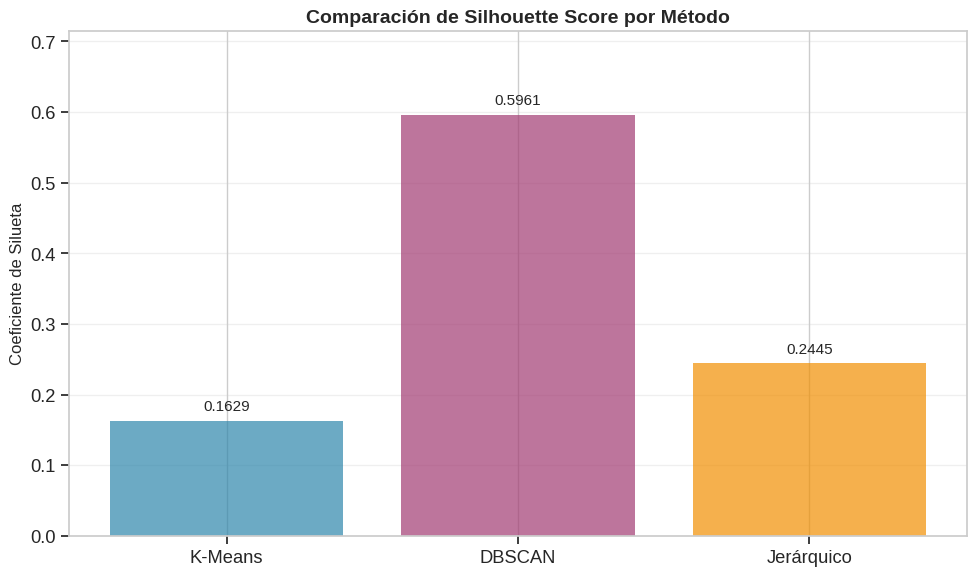

In [14]:
# ============================================
# 📊 COMPARACIÓN DE MÉTODOS DE CLUSTERING
# ============================================

print("📊 Comparando métodos de clustering...")

# Crear tabla comparativa
comparison_data = {
    'Método': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N° Clusters': [
        len(df['cluster_kmeans'].unique()),
        len(df['cluster_dbscan'].unique()) - (1 if -1 in df['cluster_dbscan'].values else 0),
        len(df['cluster_hierarchical'].unique())
    ],
    'Silhouette Score': [
        silhouette_score(X_pca_final, df['cluster_kmeans']),
        silhouette_score(X_pca_final[df['cluster_dbscan'] != -1],
                        df['cluster_dbscan'][df['cluster_dbscan'] != -1]) if len(df[df['cluster_dbscan'] != -1]) > 1 else np.nan,
        silhouette_score(X_pca_final, df['cluster_hierarchical'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# 📈 Gráfico comparativo de silhouette scores
plt.figure(figsize=(10, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(comparison_df['Método'], comparison_df['Silhouette Score'],
               color=colors, alpha=0.7)
plt.ylim(0, max(comparison_df['Silhouette Score']) * 1.2)
plt.ylabel('Coeficiente de Silueta', fontsize=12)
plt.title('Comparación de Silhouette Score por Método', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for bar, score in zip(bars, comparison_df['Silhouette Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# 💾 GUARDAR DATOS CON CLUSTERS
# ============================================

print("💾 Guardando archivo con clusters...")

# Verificar que el archivo se guarde correctamente
try:
    df.to_csv('datos_con_clusters.csv', index=False)
    print("✅ Archivo guardado exitosamente: datos_con_clusters.csv")
except Exception as e:
    print(f"❌ Error al guardar: {e}")

# 📊 Resumen final
print("\n" + "="*60)
print("📊 RESUMEN FINAL DEL ANÁLISIS")
print("="*60)

print(f"\n📌 DATOS GENERALES:")
print(f"  • Total de registros: {len(df)}")
print(f"  • Total de características: {df.shape[1] - 3}")  # Restamos las columnas de clusters

print(f"\n📌 CLUSTERS GENERADOS:")
print(f"  • K-Means: {len(df['cluster_kmeans'].unique())} clusters")
print(f"  • DBSCAN: {len(df['cluster_dbscan'].unique()) - (1 if -1 in df['cluster_dbscan'].values else 0)} clusters (+ ruido)")
print(f"  • Jerárquico: {len(df['cluster_hierarchical'].unique())} clusters")

print(f"\n📌 MÉTRICAS DE CALIDAD:")
print(f"  • K-Means Silhouette: {silhouette_score(X_pca_final, df['cluster_kmeans']):.4f}")
print(f"  • Jerárquico Silhouette: {silhouette_score(X_pca_final, df['cluster_hierarchical']):.4f}")

print(f"\n📌 COLUMNAS AÑADIDAS:")
print(f"  • cluster_kmeans")
print(f"  • cluster_dbscan")
print(f"  • cluster_hierarchical")

print("\n✅ Proceso completado exitosamente!")
print("📁 Archivo guardado: datos_con_clusters.csv")

💾 Guardando archivo con clusters...
✅ Archivo guardado exitosamente: datos_con_clusters.csv

📊 RESUMEN FINAL DEL ANÁLISIS

📌 DATOS GENERALES:
  • Total de registros: 32764
  • Total de características: 13

📌 CLUSTERS GENERADOS:
  • K-Means: 5 clusters
  • DBSCAN: 9 clusters (+ ruido)
  • Jerárquico: 5 clusters

📌 MÉTRICAS DE CALIDAD:
  • K-Means Silhouette: 0.1629
  • Jerárquico Silhouette: 0.2445

📌 COLUMNAS AÑADIDAS:
  • cluster_kmeans
  • cluster_dbscan
  • cluster_hierarchical

✅ Proceso completado exitosamente!
📁 Archivo guardado: datos_con_clusters.csv


In [16]:
# ============================================
# 📥 DESCARGAR ARCHIVO (SOLO COLAB)
# ============================================

try:
    from google.colab import files
    print("📥 Descargando archivo datos_con_clusters.csv...")
    files.download('datos_con_clusters.csv')
    print("✅ Descarga completada")
except:
    print("⚠️ Esta función solo está disponible en Google Colab")
    print("📁 Puedes descargar el archivo manualmente desde el panel de archivos")

📥 Descargando archivo datos_con_clusters.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga completada


In [17]:
# ============================================
# 📋 VISTA PREVIA DEL ARCHIVO FINAL
# ============================================

print("📋 Vista previa de los datos con clusters:")
display(df.head(10))

print("\n📊 Estadísticas de los clusters K-Means:")
display(df.groupby('cluster_kmeans').agg({
    'EDAD_JEFE': ['mean', 'std', 'min', 'max'],
    'PCT_NINOS': ['mean', 'std'],
    'NUM_OCUPADOS': ['mean', 'std']
}))

print("\n📊 Distribución de clusters K-Means por DOMINIO:")
display(pd.crosstab(df['cluster_kmeans'], df['DOMINIO']))

📋 Vista previa de los datos con clusters:


,PERCEPHO,P103,P104,P105A,EDUCACION_JEFE,DOMINIO,NUM_SERVICIOS,NUM_EQUIPOS,NUM_OCUPADOS,EDAD_JEFE,PCT_NINOS,POBREZA,HACINAMIENTO,cluster_kmeans,cluster_dbscan,cluster_hierarchical
0,2,2.0,4.0,2.0,11.0,4,8,6,1.0,45.0,0.000000,3,2.0,0,-1,0
1,2,5.0,3.0,2.0,6.0,4,8,6,2.0,42.0,0.333333,3,6.0,3,-1,0
2,2,5.0,3.0,2.0,8.0,4,8,6,2.0,44.0,0.333333,3,3.0,3,-1,0
3,1,5.0,2.0,2.0,1.0,4,8,6,1.0,78.0,0.000000,3,1.0,2,-1,0
4,2,5.0,1.0,1.0,10.0,4,8,6,2.0,33.0,0.333333,3,3.0,3,-1,0
5,2,5.0,7.0,2.0,6.0,4,8,6,2.0,64.0,0.000000,3,2.0,0,-1,0
6,1,5.0,7.0,2.0,4.0,4,8,6,0.0,76.0,0.000000,3,1.0,2,-1,0
7,2,5.0,5.0,2.0,4.0,4,8,6,2.0,68.0,0.000000,3,3.0,2,-1,0
8,2,5.0,3.0,2.0,4.0,4,8,6,1.0,56.0,0.400000,3,5.0,3,-1,0
9,2,5.0,2.0,6.0,8.0,4,8,6,2.0,27.0,0.333333,3,1.5,1,-1,0



📊 Estadísticas de los clusters K-Means:


EDAD_JEFE                        PCT_NINOS            \
                     mean        std   min   max      mean       std   
cluster_kmeans                                                         
0               56.362207  14.165775  18.0  98.0  0.053084  0.117181   
1               47.095821  15.413869  16.0  91.0  0.157710  0.199746   
2               63.904247  13.728403  17.0  98.0  0.008741  0.047896   
3               39.955457   9.676153  17.0  88.0  0.362344  0.147706   
4               55.593192  11.665935  20.0  98.0  0.118079  0.131555   

               NUM_OCUPADOS            
                       mean       std  
cluster_kmeans                         
0                  1.400820  0.803027  
1                  1.375202  0.772103  
2                  1.187838  0.745710  
3                  1.563633  0.713552  
4                  3.082238  0.978779


📊 Distribución de clusters K-Means por DOMINIO:


DOMINIO,1,2,3,4,5,6,7,8
cluster_kmeans,,,,,,,,
0,907,621,501,151,545,705,818,1605
1,432,470,395,209,814,536,947,528
2,1405,938,643,799,2123,1769,2021,662
3,876,508,371,434,995,692,1850,560
4,1103,626,304,365,891,667,1354,624
